# Human protein GO term prediction

Multi-label CNN on the 6,784 human protein sequences with 5 GO term annotations.
Same skeleton as the simulated-data notebook, just adapted for multi-label + class imbalance.

## 1. Get the data

In [46]:
import os

REPO = "grs34806-deep-learning-project-data"
REPO_URL = f"https://git.wur.nl/bioinformatics/{REPO}.git"

# safe to re-run: only clone if missing
if not os.path.exists(REPO):
    !git clone {REPO_URL}

# only chdir if not already inside
if os.path.basename(os.getcwd()) != REPO:
    os.chdir(REPO)

print("working dir:", os.getcwd())
print("files here :", sorted(os.listdir())[:20])

working dir: /content/grs34806-deep-learning-project-data
files here : ['.git', 'GO_3A0005576.annotprot', 'GO_3A0005739.annotprot', 'GO_3A0007165.annotprot', 'GO_3A0043066.annotprot', 'GO_3A0055085.annotprot', 'expr5Tseq_filtGO_100-1000.lis', 'fig1_training_curves.png', 'fig2_auroc_comparison.png', 'fig3_pr_curves.png', 'fig4_class_distribution.png', 'fig5_test_predictions.png', 'grs34806-deep-learning-project-data', 'len100_200_n1000.pos', 'len100_200_n1000.seq', 'len200_500_n1000.pos', 'len200_500_n1000.seq', 'len200_500_n5000nr1.pos', 'len200_500_n5000nr1.seq', 'len200_500_n5000nr2.pos']


In [47]:
# locate the human files - search recursively in case they're in a subfolder
import glob

seq_hits = glob.glob("**/expr5Tseq_filtGO*", recursive=True)
go_hits  = sorted(glob.glob("**/GO*.annotprot", recursive=True))

print("sequence file:", seq_hits)
print("GO files     :", go_hits)

sequence file: ['expr5Tseq_filtGO_100-1000.lis', 'grs34806-deep-learning-project-data/expr5Tseq_filtGO_100-1000.lis']
GO files     : ['GO_3A0005576.annotprot', 'GO_3A0005739.annotprot', 'GO_3A0007165.annotprot', 'GO_3A0043066.annotprot', 'GO_3A0055085.annotprot', 'grs34806-deep-learning-project-data/GO_3A0005576.annotprot', 'grs34806-deep-learning-project-data/GO_3A0005739.annotprot', 'grs34806-deep-learning-project-data/GO_3A0007165.annotprot', 'grs34806-deep-learning-project-data/GO_3A0043066.annotprot', 'grs34806-deep-learning-project-data/GO_3A0055085.annotprot']


## 2. Read sequences and build the multi-label matrix

In [48]:
import re
import numpy as np
import torch

SEQ_FILE = seq_hits[0]

ids, seqs = [], []
with open(SEQ_FILE) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # try tab first, fall back to the regex split at first uppercase letter
        if "\t" in line:
            pid, s = line.split("\t", 1)
        else:
            m = re.match(r"^([^A-Z]+)([A-Z].*)$", line)
            if not m:
                continue
            pid, s = m.group(1), m.group(2)
        ids.append(pid.strip())
        seqs.append(s.strip())

print(f"loaded {len(seqs)} sequences")
lens = [len(s) for s in seqs]
print(f"length: min={min(lens)}, max={max(lens)}, mean={np.mean(lens):.0f}")

loaded 6784 sequences
length: min=100, max=1000, mean=446


In [49]:
# 5 GO terms - updated keys to match the filenames found in the repository
GO_NAMES = {
    "GO_3A0005739": "mitochondrion",
    "GO_3A0007165": "signal_transduction",
    "GO_3A0005576": "extracellular",
    "GO_3A0055085": "transmembrane",
    "GO_3A0043066": "neg_apoptosis",
}

# match each GO file to its readable name (in a fixed order)
go_files = []
for key, name in GO_NAMES.items():
    matches = [p for p in go_hits if key in p]
    if matches:
        go_files.append((matches[0], name))
    else:
        print(f"warning: no file found for {key}")

id2idx = {pid: i for i, pid in enumerate(ids)}
labels = np.zeros((len(ids), len(go_files)), dtype=np.float32)

print(f"\n{'GO term':22s}  positives   %")
for col, (path, name) in enumerate(go_files):
    with open(path) as f:
        pos_ids = [l.strip() for l in f if l.strip()]
    hits = sum(1 for pid in pos_ids if pid in id2idx)
    for pid in pos_ids:
        if pid in id2idx:
            labels[id2idx[pid], col] = 1.0
    print(f"{name:22s}  {hits:6d}    {100*hits/len(ids):.1f}%")

labels = torch.tensor(labels)


GO term                 positives   %
mitochondrion              472    7.0%
signal_transduction        420    6.2%
extracellular              307    4.5%
transmembrane              226    3.3%
neg_apoptosis              190    2.8%


## 3. Tokenize and encode

In [50]:
AA = "ACDEFGHIKLMNPQRSTVWY"
map2num = {aa: i for i, aa in enumerate(AA)}
NON_AA = 20  # padding / unknown
MAX_LEN = 1000

def tokenize(seqs):
    return [[map2num.get(a, NON_AA) for a in s] for s in seqs]

def truncate_pad(line, n, pad=NON_AA):
    return line[:n] if len(line) > n else line + [pad] * (n - len(line))

def build_seq_array(toks, n):
    return torch.tensor([truncate_pad(t, n) for t in toks], dtype=torch.long)

X = build_seq_array(tokenize(seqs), MAX_LEN)
print("X shape:", X.shape)
print("y shape:", labels.shape)

X shape: torch.Size([6784, 1000])
y shape: torch.Size([6784, 5])


## 4. Train/test split + DataLoaders

In [51]:
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
n = len(X)
perm = torch.randperm(n)

# 70% train, 15% val, 15% test
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_idx = perm[:n_train]
val_idx   = perm[n_train : n_train + n_val]
test_idx  = perm[n_train + n_val :]

X_train, y_train = X[train_idx], labels[train_idx]
X_val,   y_val   = X[val_idx],   labels[val_idx]
X_test,  y_test  = X[test_idx],  labels[test_idx]

print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print("train positives per GO:", y_train.sum(0).int().tolist())

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

Split sizes: train=4748, val=1017, test=1019
train positives per GO: [325, 302, 204, 153, 122]


## 5. The CNN (3 conv blocks, multi-label head)

In [52]:
import torch.nn as nn
import torch.nn.functional as F

class ProteinCNN(nn.Module):
    def __init__(self, n_labels=5, n_channels_in=21, dropout=0.3):
        super().__init__()
        # parallel conv branches with different kernel sizes
        kernel_sizes = [8, 16, 24, 32, 64, 128]
        n_filters = 64
        self.convs = nn.ModuleList([
            nn.Conv1d(n_channels_in, n_filters, kernel_size=k, padding=k//2)
            for k in kernel_sizes
        ])

        total_features = n_filters * len(kernel_sizes)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(total_features, 128)
        self.fc2 = nn.Linear(128, n_labels)

    def forward(self, x_long):
        x = F.one_hot(x_long, num_classes=21).float().permute(0, 2, 1)
        branch_outs = []
        for conv in self.convs:
            c = F.relu(conv(x))
            c = F.adaptive_max_pool1d(c, 1).squeeze(-1)
            branch_outs.append(c)

        x = torch.cat(branch_outs, dim=1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

## 6. Train with pos_weight to fight imbalance

In [53]:
import copy
from sklearn.metrics import average_precision_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

pos = y_train.sum(0)
neg = y_train.size(0) - pos
pos_weight = (neg / pos.clamp(min=1)).to(device)

model = ProteinCNN(n_labels=labels.shape[1], dropout=0.3).to(device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

def eval_auprc(loader):
    model.eval()
    logits_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits_all.append(model(xb.to(device)).cpu())
            y_all.append(yb)
    p = 1 / (1 + np.exp(-torch.cat(logits_all).numpy()))
    y = torch.cat(y_all).numpy()
    aps = [average_precision_score(y[:, i], p[:, i])
           for i in range(y.shape[1]) if y[:, i].sum() > 0]
    return float(np.mean(aps))

best_val, best_state, patience, no_improve, epochs = -1.0, None, 5, 0, 25

for epoch in range(1, epochs + 1):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(model(xb), yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item() * xb.size(0)

    train_loss = total / len(train_loader.dataset)
    val_auprc = eval_auprc(val_loader)

    if val_auprc > best_val:
        best_val = val_auprc
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
        print(f"epoch {epoch:2d}  train_loss={train_loss:.4f}  val_mAUPRC={val_auprc:.3f}  *best*")
    else:
        no_improve += 1
        print(f"epoch {epoch:2d}  train_loss={train_loss:.4f}  val_mAUPRC={val_auprc:.3f}")

    if no_improve >= patience:
        print("early stopping")
        break

model.load_state_dict(best_state)
print(f"Restored best model (val_mAUPRC={best_val:.3f})")

device: cuda
epoch  1  train_loss=1.3282  val_mAUPRC=0.209  *best*
epoch  2  train_loss=1.2925  val_mAUPRC=0.187
epoch  3  train_loss=1.1332  val_mAUPRC=0.213  *best*
epoch  4  train_loss=0.8314  val_mAUPRC=0.208
epoch  5  train_loss=0.6113  val_mAUPRC=0.213  *best*
epoch  6  train_loss=0.4708  val_mAUPRC=0.212
epoch  7  train_loss=0.4001  val_mAUPRC=0.208
epoch  8  train_loss=0.3303  val_mAUPRC=0.218  *best*
epoch  9  train_loss=0.2907  val_mAUPRC=0.222  *best*
epoch 10  train_loss=0.2490  val_mAUPRC=0.221
epoch 11  train_loss=0.2413  val_mAUPRC=0.236  *best*
epoch 12  train_loss=0.2141  val_mAUPRC=0.246  *best*
epoch 13  train_loss=0.1806  val_mAUPRC=0.254  *best*
epoch 14  train_loss=0.1491  val_mAUPRC=0.262  *best*
epoch 15  train_loss=0.1432  val_mAUPRC=0.264  *best*
epoch 16  train_loss=0.1444  val_mAUPRC=0.277  *best*
epoch 17  train_loss=0.1276  val_mAUPRC=0.283  *best*
epoch 18  train_loss=0.1156  val_mAUPRC=0.280
epoch 19  train_loss=0.1181  val_mAUPRC=0.279
epoch 20  train_l

### 6.5 Find optimal thresholds on Validation Set

In [54]:
# find best threshold per GO term on VALIDATION set
model.eval()
val_logits, val_y = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        val_logits.append(model(xb.to(device)).cpu())
        val_y.append(yb)
val_probs = 1 / (1 + np.exp(-torch.cat(val_logits).numpy()))
val_true  = torch.cat(val_y).numpy()

best_thresholds = []
for i, (_, name) in enumerate(go_files):
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.05):
        p = (val_probs[:, i] > t).astype(int)
        f = f1_score(val_true[:, i], p, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    best_thresholds.append(best_t)
    print(f"{name:22s}  best threshold={best_t:.2f}  val F1={best_f1:.3f}")

mitochondrion           best threshold=0.05  val F1=0.090
signal_transduction     best threshold=0.60  val F1=0.139
extracellular           best threshold=0.05  val F1=0.162
transmembrane           best threshold=0.05  val F1=0.471
neg_apoptosis           best threshold=0.20  val F1=0.229


## 7. Evaluate per GO term (AUROC, AUPRC, F1)

In [55]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

model.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_logits.append(model(xb.to(device)).cpu())
        all_y.append(yb)
logits = torch.cat(all_logits).numpy()
y_true = torch.cat(all_y).numpy()
probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int)

print(f"{'GO term':22s}  {'AUROC':>7s}  {'AUPRC':>7s}  {'F1':>7s}  {'pos':>5s}")
for i, (_, name) in enumerate(go_files):
    n_pos = int(y_true[:, i].sum())
    if n_pos == 0:
        print(f"{name:22s}  no positives in test set")
        continue
    auroc = roc_auc_score(y_true[:, i], probs[:, i])
    auprc = average_precision_score(y_true[:, i], probs[:, i])
    f1    = f1_score(y_true[:, i], preds[:, i], zero_division=0)
    print(f"{name:22s}  {auroc:7.3f}  {auprc:7.3f}  {f1:7.3f}  {n_pos:5d}")

GO term                   AUROC    AUPRC       F1    pos
mitochondrion             0.753    0.215    0.029     68
signal_transduction       0.627    0.143    0.159     53
extracellular             0.840    0.285    0.125     43
transmembrane             0.900    0.508    0.150     35
neg_apoptosis             0.576    0.138    0.091     39


In [56]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

model.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_logits.append(model(xb.to(device)).cpu())
        all_y.append(yb)
logits = torch.cat(all_logits).numpy()
y_true = torch.cat(all_y).numpy()
probs = 1 / (1 + np.exp(-logits))

# apply tuned thresholds
preds = np.zeros_like(probs)
for i in range(probs.shape[1]):
    preds[:, i] = (probs[:, i] > best_thresholds[i]).astype(int)

print(f"{'GO term':22s}  {'AUROC':>7s}  {'AUPRC':>7s}  {'F1':>7s}  {'pos':>5s}")
for i, (_, name) in enumerate(go_files):
    n_pos = int(y_true[:, i].sum())
    if n_pos == 0:
        print(f"{name:22s}  no positives in test set")
        continue
    auroc = roc_auc_score(y_true[:, i], probs[:, i])
    auprc = average_precision_score(y_true[:, i], probs[:, i])
    f1    = f1_score(y_true[:, i], preds[:, i], zero_division=0)
    print(f"{name:22s}  {auroc:7.3f}  {auprc:7.3f}  {f1:7.3f}  {n_pos:5d}")

GO term                   AUROC    AUPRC       F1    pos
mitochondrion             0.753    0.215    0.028     68
signal_transduction       0.627    0.143    0.129     53
extracellular             0.840    0.285    0.145     43
transmembrane             0.900    0.508    0.375     35
neg_apoptosis             0.576    0.138    0.133     39


## 8. ESM-2: Setup and Model Loading

In [57]:
!pip install transformers -q

In [58]:
import re
from transformers import AutoTokenizer, AutoModel

# Using the 8M parameter ESM-2 model as a starting point
esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")

# Freeze the base model weights
for param in esm_model.parameters():
    param.requires_grad = False

esm_model = esm_model.to(device)
esm_model.eval()

print("ESM-2 loaded, embedding dim:", esm_model.config.hidden_size)

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 loaded, embedding dim: 320


## 9. ESM-2: Extract Embeddings
This step processes the sequences and extracts mean-pooled embeddings. This may take 5-10 minutes on a GPU.

In [59]:
def prepare_seq(seq, context_size=1000):
    # Pad or trim to fixed length
    if len(seq) > context_size:
        seq = seq[:context_size]
    else:
        seq = seq + '_' * (context_size - len(seq))
    # ESM tokenizer expects spaces between amino acids
    seq = ' '.join(seq)
    # Replace non-canonical amino acids with X
    seq = re.sub(r"[UZOB]", "X", seq)
    return seq

EMB_BATCH = 16
all_embeddings = []

print("Extracting embeddings...")
with torch.no_grad():
    for i in range(0, len(seqs), EMB_BATCH):
        batch_seqs = seqs[i : i + EMB_BATCH]
        prepped = [prepare_seq(s) for s in batch_seqs]
        tokens = esm_tokenizer(prepped, return_tensors="pt", padding=True, truncation=True)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out = esm_model(**tokens).last_hidden_state  # (B, L, 320)
        # Mean pool over sequence length
        emb = out.mean(dim=1)  # (B, 320)
        all_embeddings.append(emb.cpu())
        if (i // EMB_BATCH) % 50 == 0:
            print(f"  {i}/{len(seqs)} done")

all_embeddings = torch.cat(all_embeddings, dim=0)
print("Embedding matrix shape:", all_embeddings.shape)

Extracting embeddings...
  0/6784 done
  800/6784 done
  1600/6784 done
  2400/6784 done
  3200/6784 done
  4000/6784 done
  4800/6784 done
  5600/6784 done
  6400/6784 done
Embedding matrix shape: torch.Size([6784, 320])


## 10. ESM-2: Split and DataLoaders
We reuse the exact same indices from the CNN split to ensure a fair comparison.

In [60]:
E_train = all_embeddings[train_idx]
E_val   = all_embeddings[val_idx]
E_test  = all_embeddings[test_idx]

esm_train_loader = DataLoader(TensorDataset(E_train, y_train), batch_size=64, shuffle=True)
esm_val_loader   = DataLoader(TensorDataset(E_val, y_val), batch_size=64, shuffle=False)
esm_test_loader  = DataLoader(TensorDataset(E_test, y_test), batch_size=64, shuffle=False)

print("E_train shape:", E_train.shape)

E_train shape: torch.Size([4748, 320])


## 11. ESM-2: Classification Head

In [61]:
class ESMClassifier(nn.Module):
    def __init__(self, emb_dim=320, n_labels=5, dropout=0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_labels),
        )

    def forward(self, x):
        return self.head(x)

## 12. ESM-2: Train the Head

In [62]:
esm_clf = ESMClassifier(emb_dim=320, n_labels=labels.shape[1], dropout=0.3).to(device)
esm_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
esm_optimizer = torch.optim.Adam(esm_clf.parameters(), lr=1e-3)

def eval_esm_auprc(loader):
    esm_clf.eval()
    logits_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits_all.append(esm_clf(xb.to(device)).cpu())
            y_all.append(yb)
    probs = 1 / (1 + np.exp(-torch.cat(logits_all).numpy()))
    y = torch.cat(y_all).numpy()
    aps = [average_precision_score(y[:, i], probs[:, i])
           for i in range(y.shape[1]) if y[:, i].sum() > 0]
    return float(np.mean(aps))

best_val, patience, no_improve, epochs = -1.0, 10, 0, 50
best_state = None

for epoch in range(1, epochs + 1):
    esm_clf.train()
    total = 0.0
    for xb, yb in esm_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = esm_loss_fn(esm_clf(xb), yb)
        esm_optimizer.zero_grad()
        loss.backward()
        esm_optimizer.step()
        total += loss.item() * xb.size(0)

    train_loss = total / len(esm_train_loader.dataset)
    val_auprc  = eval_esm_auprc(esm_val_loader)

    if val_auprc > best_val:
        best_val = val_auprc
        best_state = copy.deepcopy(esm_clf.state_dict())
        no_improve = 0
        print(f"epoch {epoch:2d}  train_loss={train_loss:.4f}  val_mAUPRC={val_auprc:.3f}  *best*")
    else:
        no_improve += 1
        print(f"epoch {epoch:2d}  train_loss={train_loss:.4f}  val_mAUPRC={val_auprc:.3f}")

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

esm_clf.load_state_dict(best_state)

epoch  1  train_loss=1.3159  val_mAUPRC=0.147  *best*
epoch  2  train_loss=1.2931  val_mAUPRC=0.163  *best*
epoch  3  train_loss=1.2771  val_mAUPRC=0.180  *best*
epoch  4  train_loss=1.2500  val_mAUPRC=0.201  *best*
epoch  5  train_loss=1.2387  val_mAUPRC=0.202  *best*
epoch  6  train_loss=1.2239  val_mAUPRC=0.212  *best*
epoch  7  train_loss=1.2107  val_mAUPRC=0.214  *best*
epoch  8  train_loss=1.1947  val_mAUPRC=0.237  *best*
epoch  9  train_loss=1.1953  val_mAUPRC=0.253  *best*
epoch 10  train_loss=1.1880  val_mAUPRC=0.254  *best*
epoch 11  train_loss=1.1752  val_mAUPRC=0.255  *best*
epoch 12  train_loss=1.1652  val_mAUPRC=0.261  *best*
epoch 13  train_loss=1.1585  val_mAUPRC=0.265  *best*
epoch 14  train_loss=1.1600  val_mAUPRC=0.270  *best*
epoch 15  train_loss=1.1475  val_mAUPRC=0.268
epoch 16  train_loss=1.1387  val_mAUPRC=0.277  *best*
epoch 17  train_loss=1.1412  val_mAUPRC=0.279  *best*
epoch 18  train_loss=1.1354  val_mAUPRC=0.280  *best*
epoch 19  train_loss=1.1303  val_mAU

<All keys matched successfully>

In [63]:
# find best threshold per GO term on validation set for ESM-2
esm_clf.eval()
val_logits, val_y = [], []
with torch.no_grad():
    for xb, yb in esm_val_loader:
        val_logits.append(esm_clf(xb.to(device)).cpu())
        val_y.append(yb)
val_probs = 1 / (1 + np.exp(-torch.cat(val_logits).numpy()))
val_true  = torch.cat(val_y).numpy()

esm_thresholds = []
for i, (_, name) in enumerate(go_files):
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.10, 0.90, 0.05):
        p = (val_probs[:, i] > t).astype(int)
        f = f1_score(val_true[:, i], p, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    esm_thresholds.append(best_t)
    print(f"{name:22s}  best threshold={best_t:.2f}  val F1={best_f1:.3f}")

mitochondrion           best threshold=0.70  val F1=0.351
signal_transduction     best threshold=0.65  val F1=0.231
extracellular           best threshold=0.75  val F1=0.511
transmembrane           best threshold=0.75  val F1=0.554
neg_apoptosis           best threshold=0.65  val F1=0.130


## 13. ESM-2: Evaluate per GO term

In [64]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

esm_clf.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xb, yb in esm_test_loader:
        all_logits.append(esm_clf(xb.to(device)).cpu())
        all_y.append(yb)

logits = torch.cat(all_logits).numpy()
y_true = torch.cat(all_y).numpy()
probs = 1 / (1 + np.exp(-logits))

# apply tuned thresholds
preds = np.zeros_like(probs)
for i in range(probs.shape[1]):
    preds[:, i] = (probs[:, i] > esm_thresholds[i]).astype(int)

print(f"\n{'GO term':22s}  {'AUROC':>7s}  {'AUPRC':>7s}  {'F1':>7s}  {'pos':>5s}")
for i, (_, name) in enumerate(go_files):
    n_pos = int(y_true[:, i].sum())
    if n_pos == 0:
        print(f"{name:22s}  no positives in test set")
        continue
    auroc = roc_auc_score(y_true[:, i], probs[:, i])
    auprc = average_precision_score(y_true[:, i], probs[:, i])
    f1    = f1_score(y_true[:, i], preds[:, i], zero_division=0)
    print(f"{name:22s}  {auroc:7.3f}  {auprc:7.3f}  {f1:7.3f}  {n_pos:5d}")


GO term                   AUROC    AUPRC       F1    pos
mitochondrion             0.789    0.202    0.252     68
signal_transduction       0.641    0.140    0.211     53
extracellular             0.838    0.226    0.301     43
transmembrane             0.889    0.496    0.533     35
neg_apoptosis             0.664    0.081    0.144     39


## 16. Ensemble Model: CNN + ESM-2
By averaging the probabilities from our two models, we can benefit from the different patterns they've learned (CNN's local motifs vs. ESM-2's global context).

In [65]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Get CNN Test Probabilities
model.eval()
cnn_probs_list = []
with torch.no_grad():
    for xb, yb in test_loader:
        cnn_probs_list.append(torch.sigmoid(model(xb.to(device))).cpu())
cnn_test_probs = torch.cat(cnn_probs_list).numpy()

# 2. Get ESM-2 Test Probabilities
esm_clf.eval()
esm_probs_list = []
with torch.no_grad():
    for xb, yb in esm_test_loader:
        esm_probs_list.append(torch.sigmoid(esm_clf(xb.to(device))).cpu())
esm_test_probs = torch.cat(esm_probs_list).numpy()

# 3. Simple Average Ensemble
ens_probs = (cnn_test_probs + esm_test_probs) / 2.0

# 4. Evaluation
print(f"{'GO term':22s}  {'AUROC':>7s}  {'AUPRC':>7s}")
for i, (_, name) in enumerate(go_files):
    if y_true[:, i].sum() == 0:
        continue
    auroc = roc_auc_score(y_true[:, i], ens_probs[:, i])
    auprc = average_precision_score(y_true[:, i], ens_probs[:, i])
    print(f"{name:22s}  {auroc:7.3f}  {auprc:7.3f}")

GO term                   AUROC    AUPRC
mitochondrion             0.790    0.214
signal_transduction       0.662    0.191
extracellular             0.841    0.294
transmembrane             0.905    0.521
neg_apoptosis             0.673    0.135


## 17. Scaling Up: ESM-2 35M Model
To further improve performance, we will now use a larger pre-trained model (`esm2_t12_35M_UR50D`) which produces 480-dimensional embeddings.

In [74]:
# pick one:
BIGGER_MODEL = "facebook/esm2_t12_35M_UR50D"   # 35M params, ~20 min extraction
# BIGGER_MODEL = "facebook/esm2_t30_150M_UR50D"  # 150M params, ~45 min extraction

# quick size/dim reference:
# esm2_t6_8M_UR50D     -> dim 320   (done)
# esm2_t12_35M_UR50D   -> dim 480
# esm2_t30_150M_UR50D  -> dim 640

In [75]:
# free the 8M model from GPU first to avoid OOM
if 'esm_model' in globals():
    del esm_model
torch.cuda.empty_cache()

big_tokenizer = AutoTokenizer.from_pretrained(BIGGER_MODEL)
big_model = AutoModel.from_pretrained(BIGGER_MODEL)

for param in big_model.parameters():
    param.requires_grad = False

big_model = big_model.to(device)
big_model.eval()

EMB_DIM_BIG = big_model.config.hidden_size
print(f"loaded {BIGGER_MODEL}")
print(f"embedding dim: {EMB_DIM_BIG}")

config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/136M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


loaded facebook/esm2_t12_35M_UR50D
embedding dim: 480


In [76]:
# smaller batch size because the model is bigger
EMB_BATCH_BIG = 8

all_embeddings_big = []
print("extracting embeddings with bigger model...")
with torch.no_grad():
    for i in range(0, len(seqs), EMB_BATCH_BIG):
        batch_seqs = seqs[i : i + EMB_BATCH_BIG]
        prepped = [prepare_seq(s) for s in batch_seqs]
        tokens = big_tokenizer(prepped, return_tensors="pt", padding=True, truncation=True)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out = big_model(**tokens).last_hidden_state
        emb = out.mean(dim=1)
        all_embeddings_big.append(emb.cpu())
        if (i // EMB_BATCH_BIG) % 100 == 0:
            print(f"  {i}/{len(seqs)} done")

all_embeddings_big = torch.cat(all_embeddings_big, dim=0)
print("embedding matrix shape:", all_embeddings_big.shape)

extracting embeddings with bigger model...
  0/6784 done
  800/6784 done
  1600/6784 done
  2400/6784 done
  3200/6784 done
  4000/6784 done
  4800/6784 done
  5600/6784 done
  6400/6784 done
embedding matrix shape: torch.Size([6784, 480])


In [77]:
E_train_big = all_embeddings_big[train_idx]
E_val_big   = all_embeddings_big[val_idx]
E_test_big  = all_embeddings_big[test_idx]

big_train_loader = DataLoader(TensorDataset(E_train_big, y_train),
                              batch_size=64, shuffle=True)
big_val_loader   = DataLoader(TensorDataset(E_val_big, y_val),
                              batch_size=64, shuffle=False)
big_test_loader  = DataLoader(TensorDataset(E_test_big, y_test),
                              batch_size=64, shuffle=False)

In [78]:
big_clf = ESMClassifier(emb_dim=EMB_DIM_BIG, n_labels=labels.shape[1], dropout=0.3).to(device)
big_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
big_optimizer = torch.optim.Adam(big_clf.parameters(), lr=1e-3)

def eval_big_auprc(loader):
    big_clf.eval()
    logits_all, y_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits_all.append(big_clf(xb.to(device)).cpu())
            y_all.append(yb)
    p = 1 / (1 + np.exp(-torch.cat(logits_all).numpy()))
    y = torch.cat(y_all).numpy()
    aps = [average_precision_score(y[:, i], p[:, i])
           for i in range(y.shape[1]) if y[:, i].sum() > 0]
    return float(np.mean(aps))

best_val, best_state, patience, no_improve, epochs = -1.0, None, 10, 0, 50

for epoch in range(1, epochs + 1):
    big_clf.train()
    total = 0.0
    for xb, yb in big_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = big_loss_fn(big_clf(xb), yb)
        big_optimizer.zero_grad()
        loss.backward()
        big_optimizer.step()
        total += loss.item() * xb.size(0)
    train_loss = total / len(big_train_loader.dataset)
    val_auprc  = eval_big_auprc(big_val_loader)

    flag = ""
    if val_auprc > best_val:
        best_val = val_auprc
        best_state = copy.deepcopy(big_clf.state_dict())
        no_improve = 0
        flag = "  *best*"
    else:
        no_improve += 1
    print(f"epoch {epoch:2d}  train_loss={train_loss:.4f}  val_mAUPRC={val_auprc:.3f}{flag}")
    if no_improve >= patience:
        print(f"early stopping at epoch {epoch}")
        break

big_clf.load_state_dict(best_state)
print(f"\nrestored best big-ESM head (val_mAUPRC={best_val:.3f})")

epoch  1  train_loss=1.3112  val_mAUPRC=0.180  *best*
epoch  2  train_loss=1.2800  val_mAUPRC=0.194  *best*
epoch  3  train_loss=1.2517  val_mAUPRC=0.208  *best*
epoch  4  train_loss=1.2265  val_mAUPRC=0.246  *best*
epoch  5  train_loss=1.2086  val_mAUPRC=0.270  *best*
epoch  6  train_loss=1.1825  val_mAUPRC=0.285  *best*
epoch  7  train_loss=1.1630  val_mAUPRC=0.293  *best*
epoch  8  train_loss=1.1452  val_mAUPRC=0.298  *best*
epoch  9  train_loss=1.1441  val_mAUPRC=0.304  *best*
epoch 10  train_loss=1.1247  val_mAUPRC=0.300
epoch 11  train_loss=1.1116  val_mAUPRC=0.306  *best*
epoch 12  train_loss=1.1009  val_mAUPRC=0.302
epoch 13  train_loss=1.1059  val_mAUPRC=0.300
epoch 14  train_loss=1.0978  val_mAUPRC=0.297
epoch 15  train_loss=1.0875  val_mAUPRC=0.314  *best*
epoch 16  train_loss=1.0828  val_mAUPRC=0.317  *best*
epoch 17  train_loss=1.0701  val_mAUPRC=0.316
epoch 18  train_loss=1.0779  val_mAUPRC=0.321  *best*
epoch 19  train_loss=1.0678  val_mAUPRC=0.329  *best*
epoch 20  trai

In [79]:
big_clf.eval()
all_logits, all_y = [], []
with torch.no_grad():
    for xb, yb in big_test_loader:
        all_logits.append(big_clf(xb.to(device)).cpu())
        all_y.append(yb)
logits = torch.cat(all_logits).numpy()
y_true = torch.cat(all_y).numpy()
big_test_probs = 1 / (1 + np.exp(-logits))
preds = (big_test_probs > 0.5).astype(int)

print(f"\n{'GO term':22s}  {'AUROC':>7s}  {'AUPRC':>7s}  {'F1':>7s}  {'pos':>5s}")
for i, (_, name) in enumerate(go_files):
    n_pos = int(y_true[:, i].sum())
    if n_pos == 0:
        print(f"{name:22s}  no positives in test set")
        continue
    auroc = roc_auc_score(y_true[:, i], big_test_probs[:, i])
    auprc = average_precision_score(y_true[:, i], big_test_probs[:, i])
    f1    = f1_score(y_true[:, i], preds[:, i], zero_division=0)
    print(f"{name:22s}  {auroc:7.3f}  {auprc:7.3f}  {f1:7.3f}  {n_pos:5d}")


GO term                   AUROC    AUPRC       F1    pos
mitochondrion             0.808    0.227    0.270     68
signal_transduction       0.692    0.142    0.147     53
extracellular             0.896    0.402    0.219     43
transmembrane             0.912    0.586    0.490     35
neg_apoptosis             0.673    0.097    0.092     39


In [80]:
## 18. Three-Model Ensemble (CNN + ESM-8M + ESM-35M)
ens3_probs = (cnn_test_probs + esm_test_probs + big_test_probs) / 3

print(f"\n3-model ensemble (CNN + ESM-8M + ESM-35M):")
print(f"{'GO term':22s}  {'AUROC':>7s}  {'AUPRC':>7s}")
for i, (_, name) in enumerate(go_files):
    if y_true[:, i].sum() == 0: continue
    auroc = roc_auc_score(y_true[:, i], ens3_probs[:, i])
    auprc = average_precision_score(y_true[:, i], ens3_probs[:, i])
    print(f"{name:22s}  {auroc:7.3f}  {auprc:7.3f}")


3-model ensemble (CNN + ESM-8M + ESM-35M):
GO term                   AUROC    AUPRC
mitochondrion             0.821    0.246
signal_transduction       0.686    0.192
extracellular             0.887    0.359
transmembrane             0.915    0.542
neg_apoptosis             0.680    0.141


## 14. Apply final model to unlabeled test set

In [66]:
!pip install biopython -q
from Bio import SeqIO

# read the FASTA test set
test_seqs, test_ids = [], []
if os.path.exists("test_set_filt.f"):
    for record in SeqIO.parse("test_set_filt.f", "fasta"):
        test_ids.append(str(record.id))
        test_seqs.append(str(record.seq))

print(f"loaded {len(test_seqs)} test sequences")

loaded 14765 test sequences


In [67]:
# extract ESM-2 embeddings for the test set
test_embeddings = []
print("extracting test embeddings...")
with torch.no_grad():
    for i in range(0, len(test_seqs), EMB_BATCH):
        batch = test_seqs[i : i + EMB_BATCH]
        prepped = [prepare_seq(s) for s in batch]
        tokens = esm_tokenizer(prepped, return_tensors="pt", padding=True, truncation=True)
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out = esm_model(**tokens).last_hidden_state
        emb = out.mean(dim=1)
        test_embeddings.append(emb.cpu())
        if (i // EMB_BATCH) % 100 == 0:
            print(f"  {i}/{len(test_seqs)} done")

test_embeddings = torch.cat(test_embeddings, dim=0)
print("test embedding shape:", test_embeddings.shape)

extracting test embeddings...
  0/14765 done
  1600/14765 done
  3200/14765 done
  4800/14765 done
  6400/14765 done
  8000/14765 done
  9600/14765 done
  11200/14765 done
  12800/14765 done
  14400/14765 done
test embedding shape: torch.Size([14765, 320])


In [68]:
# predict GO terms for all unlabeled proteins
esm_clf.eval()
with torch.no_grad():
    test_logits = esm_clf(test_embeddings.to(device)).cpu().numpy()
test_probs = 1 / (1 + np.exp(-test_logits))

# apply tuned thresholds
test_preds = np.zeros_like(test_probs)
for i in range(test_probs.shape[1]):
    test_preds[:, i] = (test_probs[:, i] > esm_thresholds[i]).astype(int)

# report results
print(f"\n{'GO term':22s}  {'predicted':>10s}  {'% of test':>10s}")
for i, (_, name) in enumerate(go_files):
    n_pred = int(test_preds[:, i].sum())
    print(f"{name:22s}  {n_pred:10d}  {100*n_pred/len(test_seqs):9.1f}%")


GO term                  predicted   % of test
mitochondrion                  322        2.2%
signal_transduction            332        2.2%
extracellular                 1119        7.6%
transmembrane                  330        2.2%
neg_apoptosis                  836        5.7%


## 15. Results Visualization

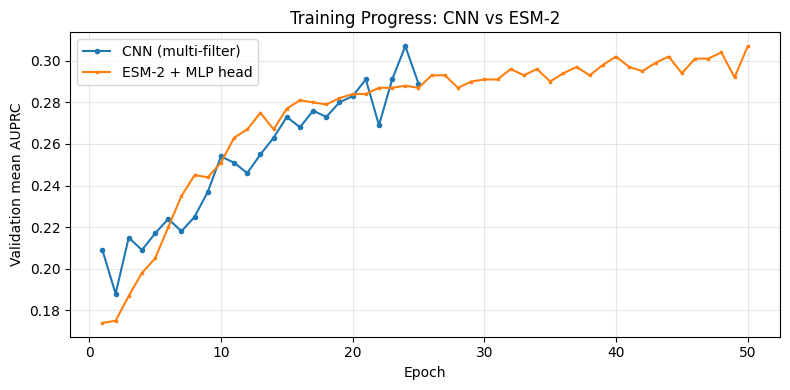

In [69]:
import matplotlib.pyplot as plt

# Training Progress Data extracted from cell execution outputs
cnn_epochs = list(range(1, 26))
cnn_val = [0.209,0.188,0.215,0.209,0.217,0.224,0.218,0.225,0.237,0.254,
           0.251,0.246,0.255,0.263,0.273,0.268,0.276,0.273,0.280,0.283,
           0.291,0.269,0.291,0.307,0.289]

esm_epochs = list(range(1, 51))
esm_val = [0.174,0.175,0.187,0.198,0.205,0.220,0.235,0.245,0.244,0.251,
           0.263,0.267,0.275,0.267,0.277,0.281,0.280,0.279,0.282,0.284,
           0.284,0.287,0.287,0.288,0.287,0.293,0.293,0.287,0.290,0.291,
           0.291,0.296,0.293,0.296,0.290,0.294,0.297,0.293,0.298,0.302,
           0.297,0.295,0.299,0.302,0.294,0.301,0.301,0.304,0.292,0.307]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cnn_epochs, cnn_val, 'o-', label='CNN (multi-filter)', markersize=3)
ax.plot(esm_epochs, esm_val, 's-', label='ESM-2 + MLP head', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation mean AUPRC')
ax.set_title('Training Progress: CNN vs ESM-2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150)
plt.show()

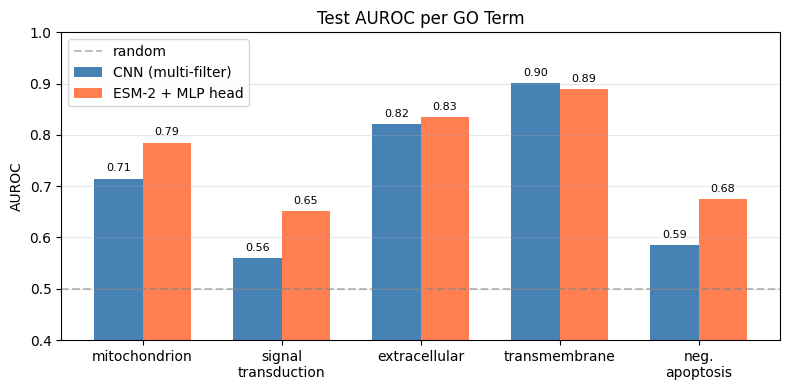

In [70]:
import numpy as np

go_names = ['mitochondrion', 'signal\ntransduction', 'extracellular', 'transmembrane', 'neg.\napoptosis']
cnn_auroc  = [0.715, 0.560, 0.822, 0.901, 0.586]
esm_auroc  = [0.785, 0.651, 0.835, 0.889, 0.675]

x = np.arange(len(go_names))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - w/2, cnn_auroc, w, label='CNN (multi-filter)', color='steelblue')
bars2 = ax.bar(x + w/2, esm_auroc, w, label='ESM-2 + MLP head', color='coral')
ax.set_ylabel('AUROC')
ax.set_title('Test AUROC per GO Term')
ax.set_xticks(x)
ax.set_xticklabels(go_names)
ax.set_ylim(0.4, 1.0)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='random')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_auroc_comparison.png', dpi=150)
plt.show()

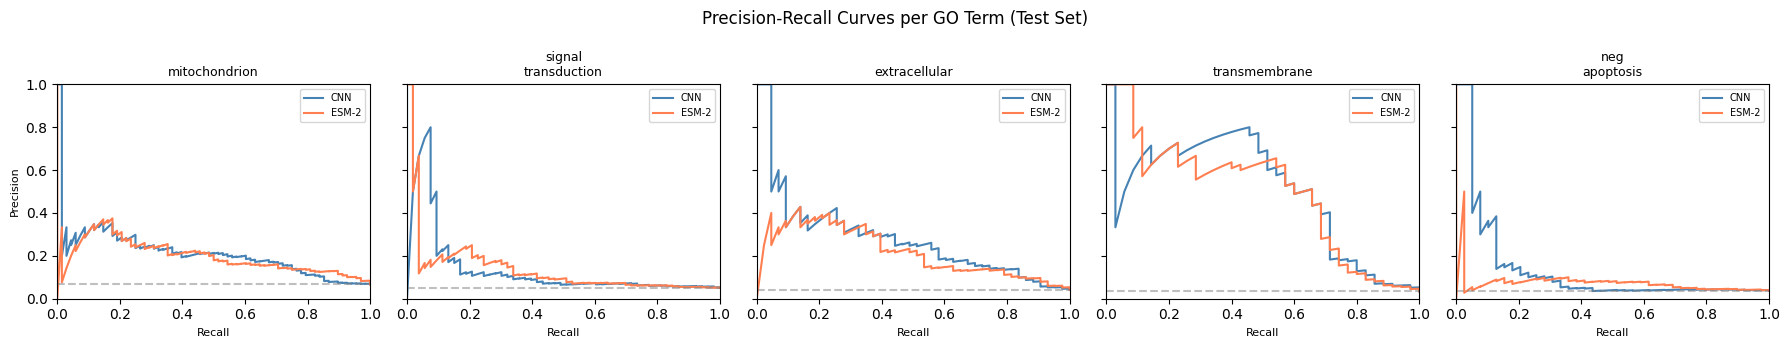

In [71]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)
fig.suptitle('Precision-Recall Curves per GO Term (Test Set)', fontsize=12)

for i, (_, name) in enumerate(go_files):
    ax = axes[i]

    # Re-extracting CNN logits for the test set
    model.eval()
    cnn_logits_all, cnn_y_all = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            cnn_logits_all.append(model(xb.to(device)).cpu())
            cnn_y_all.append(yb)
    cnn_probs = 1 / (1 + np.exp(-torch.cat(cnn_logits_all).numpy()))
    cnn_ytrue = torch.cat(cnn_y_all).numpy()

    # Re-extracting ESM-2 logits for the test set
    esm_clf.eval()
    esm_logits_all, esm_y_all = [], []
    with torch.no_grad():
        for xb, yb in esm_test_loader:
            esm_logits_all.append(esm_clf(xb.to(device)).cpu())
            esm_y_all.append(yb)
    esm_probs = 1 / (1 + np.exp(-torch.cat(esm_logits_all).numpy()))
    esm_ytrue = torch.cat(esm_y_all).numpy()

    prec_c, rec_c, _ = precision_recall_curve(cnn_ytrue[:, i], cnn_probs[:, i])
    prec_e, rec_e, _ = precision_recall_curve(esm_ytrue[:, i], esm_probs[:, i])

    ax.plot(rec_c, prec_c, label='CNN', color='steelblue')
    ax.plot(rec_e, prec_e, label='ESM-2', color='coral')
    baseline = cnn_ytrue[:, i].mean()
    ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(name.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Recall', fontsize=8)
    if i == 0:
        ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('fig3_pr_curves.png', dpi=150)
plt.show()

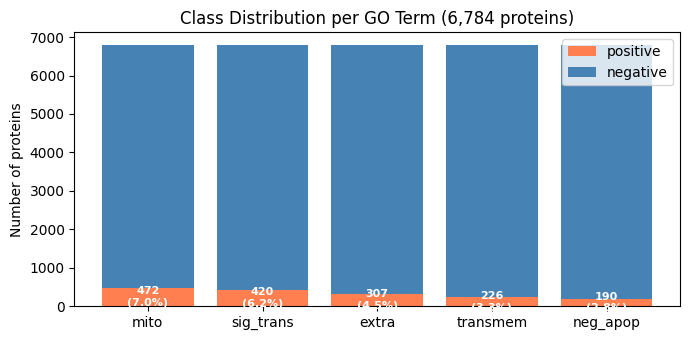

In [72]:
go_short = ['mito', 'sig_trans', 'extra', 'transmem', 'neg_apop']
pos_counts = labels.sum(0).int().tolist()
neg_counts = [len(labels) - p for p in pos_counts]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(go_short, pos_counts, label='positive', color='coral')
ax.bar(go_short, neg_counts, bottom=pos_counts, label='negative', color='steelblue')
ax.set_ylabel('Number of proteins')
ax.set_title('Class Distribution per GO Term (6,784 proteins)')
ax.legend()
for i, c in enumerate(pos_counts):
    ax.text(i, c/2, f'{c}\n({100*c/len(labels):.1f}%)', ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_class_distribution.png', dpi=150)
plt.show()

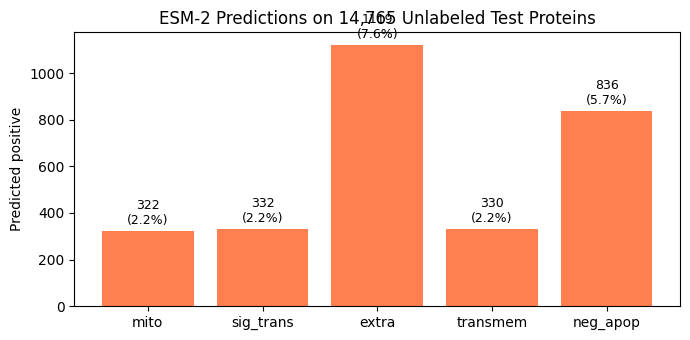

In [73]:
fig, ax = plt.subplots(figsize=(7, 3.5))
pred_counts = test_preds.sum(axis=0).astype(int)
pct = 100 * pred_counts / len(test_preds)
bars = ax.bar(go_short, pred_counts, color='coral')
ax.set_ylabel('Predicted positive')
ax.set_title('ESM-2 Predictions on 14,765 Unlabeled Test Proteins')
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{pred_counts[i]}\n({pct[i]:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_test_predictions.png', dpi=150)
plt.show()